In [80]:
import pandas as pd
from matplotlib import pyplot as plt

In [81]:
dfs = []
for i in range(1, 21):
    dfs.append(pd.read_csv(f'../metrics/results_{i}_steps.csv', delimiter=';', quotechar='"'))

df = pd.concat(dfs, ignore_index=True)

In [82]:
df

,autoregression_steps,metric,mean/std,variable,level,lat_weighted,value
0,1,mae,mean,all,-1,False,0.037572
1,1,mae,std,all,-1,False,0.001924
2,1,mse,mean,all,-1,False,0.003673
3,1,mse,std,all,-1,False,0.000328
4,1,rmse,mean,all,-1,False,0.060549
...,...,...,...,...,...,...,...
8635,20,mae,std,geopotential,4,True,0.024831
8636,20,mse,mean,geopotential,4,True,0.012776
8637,20,mse,std,geopotential,4,True,0.007713
8638,20,rmse,mean,geopotential,4,True,0.106820


In [83]:
df = df[df.metric == 'mae']
df = df[df.variable == 'all']
df = df[df.lat_weighted == False]
df_mean = df[df["mean/std"] == "mean"]
df_mean = df_mean[df_mean["autoregression_steps"] % 6 == 0]
df_mean = df_mean.drop(labels=["metric", "mean/std", "variable", "level", "lat_weighted"], axis=1)
df_std = df[df["mean/std"] == "std"]

print(df_mean)

      autoregression_steps     value
2160                     6  0.077984
4752                    12  0.044477
7344                    18  0.077986


In [84]:
over_all_vars = df[df.variable == "all"]

means = over_all_vars[over_all_vars["mean/std"] == "mean"]
lat_means = means[means.lat_weighted == True]
means = means[means.lat_weighted == False]
lat_means = lat_means.drop(["mean/std", "lat_weighted", "variable", "level"], axis=1)
means = means.drop(["mean/std", "lat_weighted", "variable", "level"], axis=1)
lat_means = lat_means.rename(columns={'value': 'mean'})
means = means.rename(columns={'value': 'mean'})

stds = over_all_vars[over_all_vars["mean/std"] == "std"]
lat_stds = stds[stds.lat_weighted == True]
stds = stds[stds.lat_weighted == False]
lat_stds = lat_stds.drop(["mean/std", "lat_weighted", "variable", "level"], axis=1)
stds = stds.drop(["mean/std", "lat_weighted", "variable", "level"], axis=1)
lat_stds = lat_stds.rename(columns={'value': 'std'})
stds = stds.rename(columns={'value': 'std'})

mean_over_vars = pd.merge(means, stds, on=['autoregression_steps', 'metric'])
mean_over_vars_lat = pd.merge(lat_means, lat_stds, on=['autoregression_steps', 'metric'])

In [85]:
metric_colors = {'mae': 'blue', 'mse': 'green', 'rmse': 'red'}


def plot_mean_std(df):
    plt.figure(figsize=(10, 6))

    for metric in df['metric'].unique():
        metric_data = df[df['metric'] == metric]
        plt.plot(
            metric_data['autoregression_steps'],
            metric_data['mean'],
            label=metric,
            color=metric_colors[metric]
        )
        plt.fill_between(
            metric_data['autoregression_steps'],
            metric_data['mean'] - metric_data['std'],
            metric_data['mean'] + metric_data['std'],
            color=metric_colors[metric],
            alpha=0.2
        )

    plt.title('Fehlerkennzahlen über autoregressive Schritte')
    plt.xlabel('Autoregressive Schritte')
    plt.ylabel('Fehler (Mittelwert ± Standardabweichung)')
    plt.legend(title='Metrik')
    plt.grid(True)
    plt.show()


color_dict = {
    0: (0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0),
    1: (0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0),
    2: (0.6823529411764706, 0.7803921568627451, 0.9098039215686274, 1.0),
    3: (0.6823529411764706, 0.7803921568627451, 0.9098039215686274, 1.0),
    4: (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
    5: (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
    6: (1.0, 0.7333333333333333, 0.47058823529411764, 1.0),
    7: (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0),
    8: (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0),
    9: (0.596078431372549, 0.8745098039215686, 0.5411764705882353, 1.0),
    10: (0.596078431372549, 0.8745098039215686, 0.5411764705882353, 1.0),
    11: (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0),
    12: (1.0, 0.596078431372549, 0.5882352941176471, 1.0),
    13: (1.0, 0.596078431372549, 0.5882352941176471, 1.0),
    14: (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0),
    15: (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0),
    16: (0.7725490196078432, 0.6901960784313725, 0.8352941176470589, 1.0),
    17: (0.5490196078431373, 0.33725490196078434, 0.29411764705882354, 1.0),
    18: (0.5490196078431373, 0.33725490196078434, 0.29411764705882354, 1.0),
    19: (0.7686274509803922, 0.611764705882353, 0.5803921568627451, 1.0),
    20: (0.7686274509803922, 0.611764705882353, 0.5803921568627451, 1.0),
    21: (0.8901960784313725, 0.4666666666666667, 0.7607843137254902, 1.0),
    22: (0.8901960784313725, 0.4666666666666667, 0.7607843137254902, 1.0),
    23: (0.9686274509803922, 0.7137254901960784, 0.8235294117647058, 1.0),
    24: (0.4980392156862745, 0.4980392156862745, 0.4980392156862745, 1.0),
    25: (0.4980392156862745, 0.4980392156862745, 0.4980392156862745, 1.0),
    26: (0.7803921568627451, 0.7803921568627451, 0.7803921568627451, 1.0),
    27: (0.7803921568627451, 0.7803921568627451, 0.7803921568627451, 1.0),
    28: (0.7372549019607844, 0.7411764705882353, 0.13333333333333333, 1.0),
    29: (0.8588235294117647, 0.8588235294117647, 0.5529411764705883, 1.0),
    30: (0.8588235294117647, 0.8588235294117647, 0.5529411764705883, 1.0),
    31: (0.09019607843137255, 0.7450980392156863, 0.8117647058823529, 1.0),
    32: (0.09019607843137255, 0.7450980392156863, 0.8117647058823529, 1.0),
    33: (0.6196078431372549, 0.8549019607843137, 0.8980392156862745, 1.0),
    34: (0.6196078431372549, 0.8549019607843137, 0.8980392156862745, 1.0)
}


def plot_variable_data(df):
    """
    Plots data for each variable with separate lines and error bands.

    Parameters:
    df (DataFrame): The DataFrame containing the data. It should have columns:
        'variable', 'autoregression_steps', 'mean', and 'std'.
    variable_colors (dict): A dictionary mapping each variable to a color.
    """
    plt.figure(figsize=(10, 6))

    for idx, variable in enumerate(df['variable'].unique()):
        variable_data = df[df['variable'] == variable]
        plt.plot(
            variable_data['autoregression_steps'],
            variable_data['mean'],
            label=variable,
            color=color_dict.get(idx, 'black')  # Default to 'black' if no color specified
        )
        plt.fill_between(
            variable_data['autoregression_steps'],
            variable_data['mean'] - variable_data['std'],
            variable_data['mean'] + variable_data['std'],
            color=color_dict.get(idx, 'black'),
            alpha=0.2
        )

    plt.title('Daten pro Variable über autoregressive Schritte')
    plt.xlabel('Autoregressive Schritte')
    plt.ylabel('Datenwert (Mittelwert ± Standardabweichung)')
    plt.legend(title='Variable')
    plt.grid(True)
    plt.show()

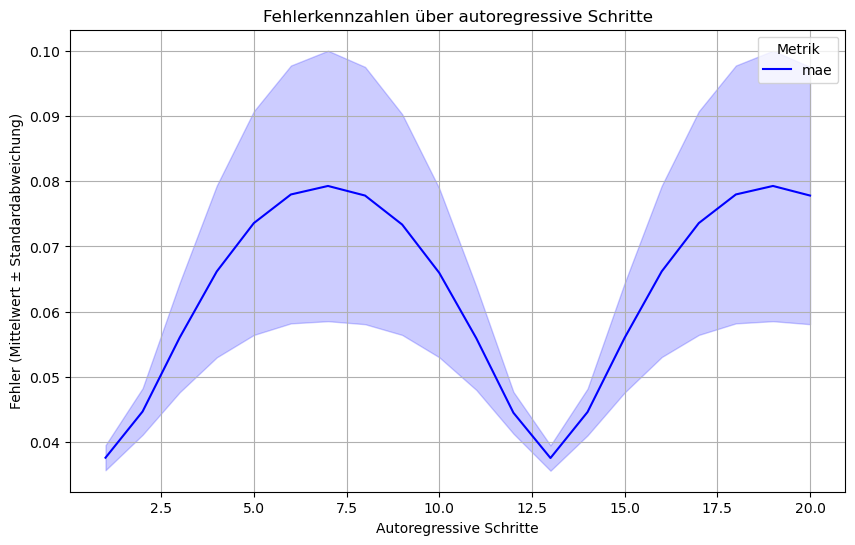

In [86]:
plot_mean_std(mean_over_vars)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


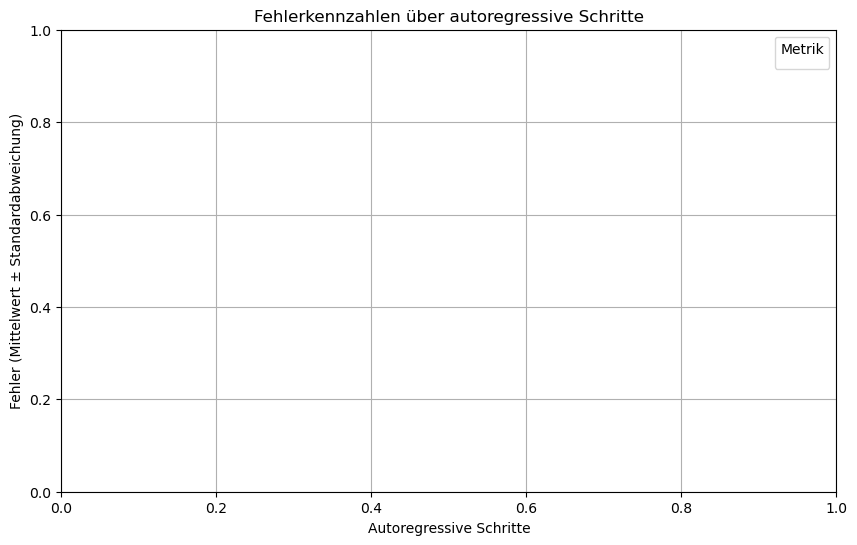

In [87]:
plot_mean_std(mean_over_vars_lat)

In [88]:
over_vars = df[df.variable != "all"]
over_vars = over_vars.pivot_table(
    index=["autoregression_steps", "metric", "variable", "level", "lat_weighted"],
    columns="mean/std",
    values="value"
).reset_index()

level_vars = over_vars[over_vars.level >= 0]
level_vars = level_vars[level_vars.metric == 'mae']
surface_vars = over_vars[over_vars.level == -1]

In [89]:
for level in set(level_vars.level):
    plot_df = level_vars[level_vars.level == level]
    # print(plot_df)
    plot_variable_data(plot_df)

In [90]:
import torch
import numpy as np

a = torch.tensor(np.array([1, 2, np.NaN]))
mask = ~torch.isnan(a)
a * mask

tensor([1., 2., nan], dtype=torch.float64)

In [91]:
outs = [torch.tensor(np.random.rand(16,35,121,240)) for i in range(1)]
stacked_outs = torch.stack(outs, dim=1)
stacked_outs.shape

torch.Size([16, 1, 35, 121, 240])

In [92]:
model_input = torch.rand((16,35,121,240))
a = torch.rand((16,2,35,121,240))
a[:,1,:,:,:].shape

torch.Size([16, 35, 121, 240])